In [1]:
import sys
sys.path.append('../../../')

In [2]:
from CADETProcess.processModel import ComponentSystem
from CADETProcess.processModel import Linear
from CADETProcess.processModel import Inlet, LumpedRateModelWithPores

# Component System
component_system = ComponentSystem(['A', 'B'])

# Binding Model
binding_model = Linear(component_system)
binding_model.is_kinetic = True
binding_model.adsorption_rate = [2, 3]
binding_model.desorption_rate = [1, 1]

# Column
column = LumpedRateModelWithPores(component_system, name='column')
column.binding_model = binding_model

column.length = 0.6
column.diameter = 0.025
column.bed_porosity = 0.4

column.particle_porosity = 0.7
column.particle_radius = 5.0e-6
column.film_diffusion = component_system.n_comp*[1e-5]

column.axial_dispersion = 1e-8

eluent = Inlet(component_system, name='eluent')
eluent.c = [0, 0]
eluent.flow_rate = 7e-7

feed = Inlet(component_system, name='feed')
feed.c = [10, 10]
feed.flow_rate = 4e-7

In [3]:
from CADETProcess.modelBuilder import SMBBuilder

smb_builder = SMBBuilder(feed, eluent, column)
smb_builder.switch_time = 100

w_e = 0.14
smb_builder.set_output_state('zone_I', [w_e, 1-w_e])

w_r = 0.13
smb_builder.set_output_state('zone_III', [w_r, 1-w_r])

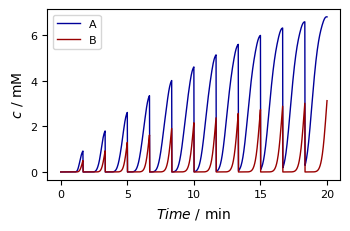

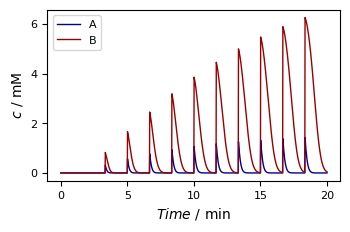

In [4]:
process = smb_builder.build_process()

from CADETProcess.simulator import Cadet
process_simulator = Cadet()
process_simulator.n_cycles = 3

simulation_results = process_simulator.simulate(process)

_ = simulation_results.solution.raffinate.inlet.plot()
_ = simulation_results.solution.extract.inlet.plot()

In [5]:
from CADETProcess.modelBuilder import LinearSMBBuilder

smb_builder = LinearSMBBuilder(feed, eluent, column)
smb_builder.switch_time = 100

Q_feed, Q_eluent, w_r, w_e = smb_builder.triangle_design()
print(Q_feed, Q_eluent, w_r, w_e)

5.301437602932773e-07 5.301437602932773e-07 0.13235294117647053 0.13235294117647053


C:\Users\ezeiry\Documents\CADET-Process\CADETProcess\modelBuilder\carouselBuilder.py:1013: UserWarning: Isotherm uses kinetic binding, however, triangle theory assumes instant equilibrium.
  warnings.warn(


In [6]:
Q_feed, Q_eluent, w_r, w_e = smb_builder.triangle_design(gamma=1.05)
print(Q_feed, Q_eluent, w_r, w_e)

4.013945613649104e-07 6.601552062699625e-07 0.12847965738758033 0.13626532083633752


In [7]:
_ = smb_builder.plot_triangle(gamma=1.05)

In [8]:
process = smb_builder.build_process()

from CADETProcess.simulator import Cadet
process_simulator = Cadet()
process_simulator.n_cycles = 3

simulation_results = process_simulator.simulate(process)

_ = simulation_results.solution.raffinate.inlet.plot()
_ = simulation_results.solution.extract.inlet.plot()